# **📓 Notebook Pratique : De la Théorie à la Pratique des RNNs**

Ce notebook est dédié aux Réseaux de Neurones Récurrents (RNN). Avant de faire appel à la puissance des bibliothèques comme Keras ou PyTorch, nous allons ouvrir le capot.


L'Intelligence Artificielle n'a rien de magique: ce ne sont que des multiplications matricielles.

## **🎬 Acte 1 : Le RNN "Fait Maison" (Démystifier la boîte noire)**

Rappelons l'équation fondamentale du cœur d'un RNN vue en cours. À chaque pas de temps $t$, la mémoire du réseau (l'état caché $h_t$) est mise à jour ainsi :

$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b_h)$$

**Notre objectif ici :** Coder cette formule strictement avec `numpy` pour comprendre comment un réseau lit une petite séquence temporelle (ex: 3 jours de température) et met à jour sa mémoire.

In [ ]:
import numpy as np

# ---------------------------------------------------------
# 1. Définition du problème et des dimensions
# ---------------------------------------------------------
# Imaginons que nous lisons la température sur 3 jours consécutifs
sequence_x = [20.0, 22.0, 25.0]

# Dimensions de notre mini-réseau
d_x = 1  # Taille de l'entrée (1 seule variable : la température)
d_h = 2  # Taille de l'état caché (notre réseau a "2 neurones" de mémoire)

# ---------------------------------------------------------
# 2. Initialisation des Matrices de Poids (Les paramètres "appris")
# ---------------------------------------------------------
# Pour l'exemple, nous fixons ces poids manuellement (en réalité, l'IA les apprendrait)
W_x = np.array([[0.1],
                [-0.2]]) # Dimension (2, 1)

W_h = np.array([[0.8, 0.2],
                [0.1, 0.5]]) # Dimension (2, 2)

b_h = np.array([[0.05],
                [-0.05]]) # Dimension (2, 1)

# L'état caché initial (Avant le jour 1, le réseau n'a aucun souvenir)
h_t = np.zeros((d_h, 1)) # Vecteur de zéros de dimension (2, 1)

# ---------------------------------------------------------
# 3. La Boucle Temporelle (Le coeur du RNN)
# ---------------------------------------------------------
print("🚀 Début de la lecture de la séquence temporelle :\n")
print(f"État initial (h_0) :\n{h_t}\n")

# Nous parcourons la séquence jour après jour (pas de temps par pas de temps)
for t, x_val in enumerate(sequence_x):

    # Étape A : Formater l'entrée x_t en vecteur colonne (1, 1)
    x_t = np.array([[x_val]])

    # Étape B : Application stricte de la formule mathématique
    # 1. Influence du passé : W_h * h_{t-1}
    influence_passe = np.dot(W_h, h_t)

    # 2. Influence du présent : W_x * x_t
    influence_present = np.dot(W_x, x_t)

    # 3. Calcul du nouvel état (avant activation)
    z_t = influence_passe + influence_present + b_h

    # 4. Activation non-linéaire (écrasement entre -1 et 1)
    h_t = np.tanh(z_t)

    # Affichage pédagogique
    print(f"--- Temps t={t+1} | Lecture de la température : {x_val}°C ---")
    print(f"Nouvel état caché (h_{t+1}) :\n{h_t}\n")

print("✅ Lecture terminée ! Le vecteur h_3 contient le résumé mathématique de ces 3 jours.")

🚀 Début de la lecture de la séquence temporelle :

État initial (h_0) :
[[0.]
 [0.]]

--- Temps t=1 | Lecture de la température : 20.0°C ---
Nouvel état caché (h_1) :
[[ 0.967395  ]
 [-0.99939311]]

--- Temps t=2 | Lecture de la température : 22.0°C ---
Nouvel état caché (h_2) :
[[ 0.99297616]
 [-0.99987816]]

--- Temps t=3 | Lecture de la température : 25.0°C ---
Nouvel état caché (h_3) :
[[ 0.99629295]
 [-0.99996313]]

✅ Lecture terminée ! Le vecteur h_3 contient le résumé mathématique de ces 3 jours.


### **Que venons-nous de prouver?**

Prenez le temps d'observer les résultats générés par le code ci-dessus :

1. **La Dimension :** Notre entrée $x_t$ était un simple nombre (la température). Mais notre état caché $h_t$ est un vecteur de taille 2. Le réseau a "projeté" une donnée simple dans un espace mathématique plus riche pour pouvoir y stocker du contexte.


2. **Le Partage des Poids :**  Avez-vous remarqué que les matrices `W_x` et `W_h` n'ont **jamais changé** dans la boucle `for` ? C'est le principe fondateur du RNN : on réutilise la même mécanique d'inférence, quel que soit l'instant $t$.


3. **La saturation ($\tanh$):**  Remarquez comment les valeurs de $h_t$ restent contraintes entre -1 et 1. C'est le rôle de la fonction tangente hyperbolique. Si nous avions utilisé une activation linéaire, après 100 jours d'itérations, les valeurs auraient explosé vers l'infini.

**Maintenant que le mystère mathématique est levé, nous sommes prêts à affronter le plus grand défi en Deep Learning Séquentiel : le formatage des données (Le Tenseur 3D).**

## **🎬 Acte 2 : Le Souci du Tenseur 3D (Résolu)**

Dans ce qui précède, nous avons vu comment le RNN traite une séquence pas à pas. Mais comment nourrit-on un réseau de neurones avec des années d'historique ?


L'erreur classique des débutants est de donner toute la série temporelle d'un seul coup.

 Or, pour que l'IA apprenne à généraliser, elle a besoin de s'entraîner sur de multiples "exemples" tirés de cette série. Nous devons découper notre série en **fenêtres glissantes** (Sliding Windows).


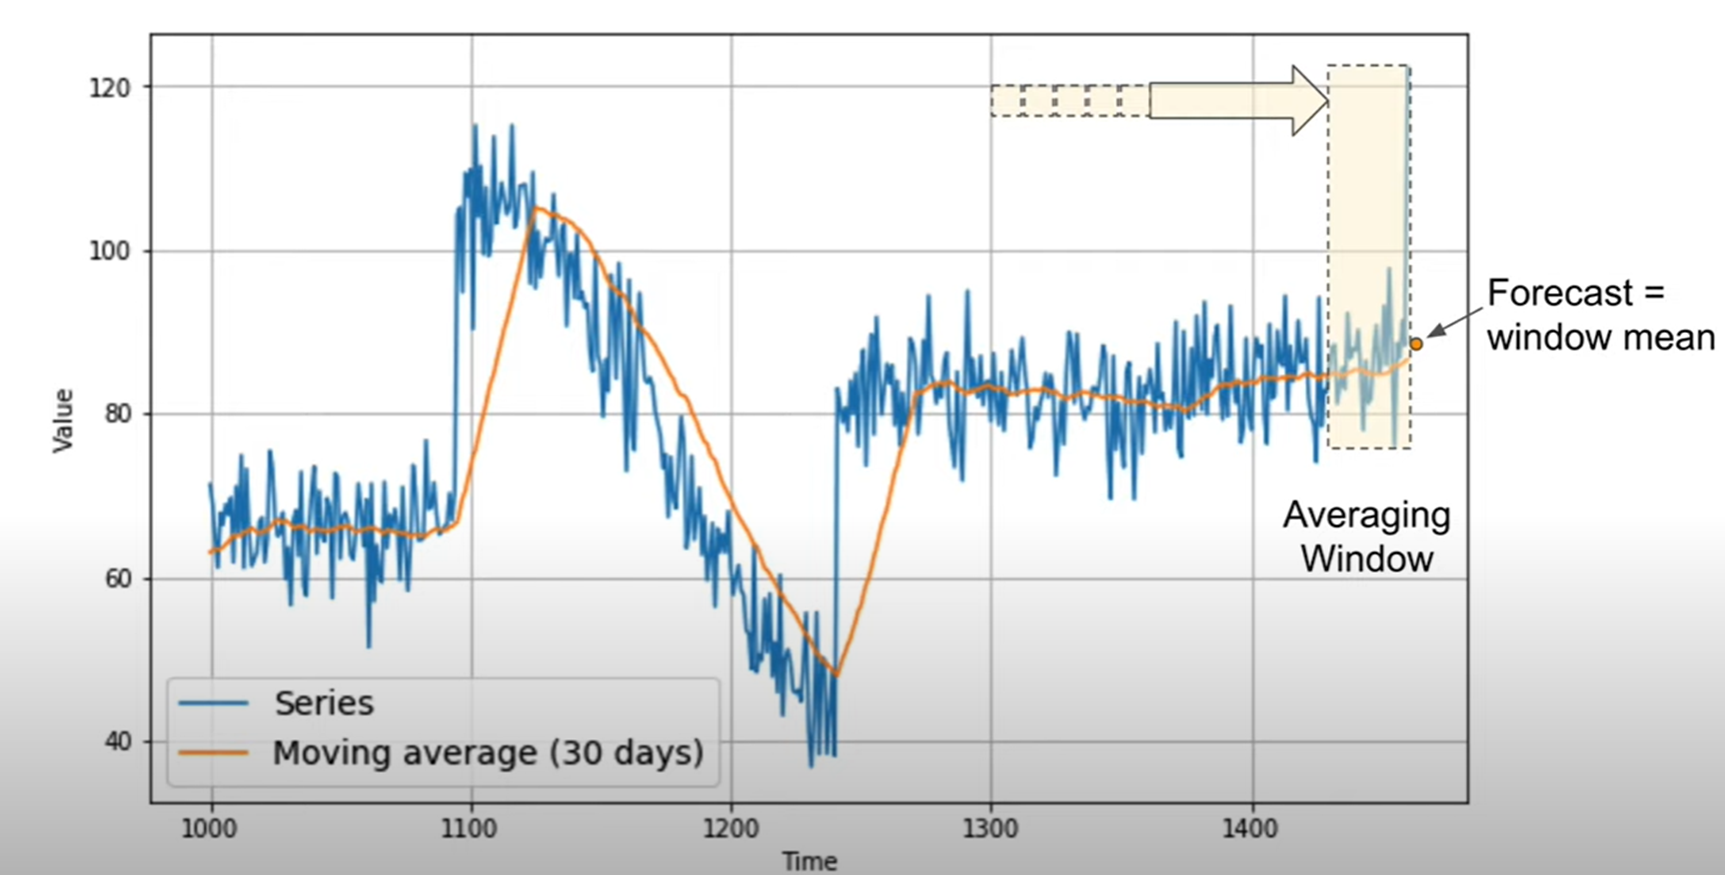

### **Le Saint Graal du Deep Learning Séquentiel : `(batch_size, time_steps, features)`**

Toutes les bibliothèques d'IA (Keras, PyTorch, TensorFlow) exigent que les données séquentielles soient formatées dans un **Tenseur à 3 dimensions (3D)**.

Comprendre ces 3 axes est la clé absolue :

1. **Axe 0 - `batch_size` (Les Échantillons) :** Combien de "fenêtres" ou d'exemples avons-nous découpés dans notre historique ?


2. **Axe 1 - `time_steps` (Les Pas de temps) :** Quelle est la taille de notre fenêtre (notre mémoire) ? Combien de jours l'algorithme a-t-il le droit de regarder en arrière ?


3. **Axe 2 - `features` (Les Caractéristiques) :** Combien de variables mesurons-nous par jour ? (ex: 1 si on n'a que la température, 2 si on a la température + l'humidité).


Passons à la pratique en transformant une simple liste de 9 chiffres en un magnifique tenseur 3D !

In [ ]:
import numpy as np

# 1. Notre série temporelle brute (1D)
# Imaginons les ventes quotidiennes sur 9 jours
serie_brute = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90])
print(f"📊 Série brute originale (Taille {serie_brute.shape}) :\n{serie_brute}\n")

# 2. Définition de notre "vision"
TIME_STEPS = 3  # Le modèle regardera 3 jours en arrière (x)
HORIZON = 1     # Le modèle devra prédire le 1 jour suivant (y)

# 3. La fonction de fenêtrage (Sliding Window)
def creer_dataset(serie, time_steps):
    X, y = [], []
    # On glisse sur la série jusqu'à ce qu'il n'y ait plus assez de jours pour faire une fenêtre + une cible
    for i in range(len(serie) - time_steps):
        fenetre = serie[i : i + time_steps] # Les 3 jours d'historique
        cible = serie[i + time_steps]       # Le 4ème jour à prédire

        X.append(fenetre)
        y.append(cible)

    return np.array(X), np.array(y)

# Application de la fonction
X_2D, y_1D = creer_dataset(serie_brute, TIME_STEPS)

print(f"✂️ Après découpage (Fenêtres de {TIME_STEPS} jours) :")
print(f"Format de X : {X_2D.shape} -> C'est une Matrice 2D (Lignes, Colonnes) !")
print("Aperçu de X_2D :")
for i in range(len(X_2D)):
    print(f"Échantillon {i+1} : {X_2D[i]} ---> Cible à prédire : {y_1D[i]}")

📊 Série brute originale (Taille (9,)) :
[10 20 30 40 50 60 70 80 90]

✂️ Après découpage (Fenêtres de 3 jours) :
Format de X : (6, 3) -> C'est une Matrice 2D (Lignes, Colonnes) !
Aperçu de X_2D :
Échantillon 1 : [10 20 30] ---> Cible à prédire : 40
Échantillon 2 : [20 30 40] ---> Cible à prédire : 50
Échantillon 3 : [30 40 50] ---> Cible à prédire : 60
Échantillon 4 : [40 50 60] ---> Cible à prédire : 70
Échantillon 5 : [50 60 70] ---> Cible à prédire : 80
Échantillon 6 : [60 70 80] ---> Cible à prédire : 90


### **Le format actuel (2D) n'est pas suffisant!**

Regardez la forme de notre `X_2D` : `(6, 3)`.
* **6** échantillons (batch_size)
* **3** jours par échantillon (time_steps)



Pour un algorithme classique (comme la Régression Linéaire ou un Random Forest), ce format 2D est parfait. L'algorithme verrait "3 colonnes indépendantes".



**Mais le RNN est différent !** Il a besoin de savoir combien de variables (features) il y a ***à l'intérieur*** de chaque pas de temps.

Même si nous n'avons qu'une seule variable (les ventes), nous devons l'expliciter en rajoutant une 3ème dimension de taille **1**.



Transformons notre matrice `(6, 3)` en un tenseur `(6, 3, 1)`.

###**Le Reshape (La naissance du Tenseur)**

In [ ]:
# ---------------------------------------------------------
# Le Reshape : Ajout de la dimension 'features'
# ---------------------------------------------------------
FEATURES = 1 # Nous n'avons qu'une seule variable (les ventes)

# On utilise np.reshape pour forcer le format 3D
X_3D = np.reshape(X_2D, (X_2D.shape[0], X_2D.shape[1], FEATURES))

print("🪄 Transformation magique vers la 3D :")
print(f"Nouveau format de X : {X_3D.shape}")
print(f"- Batch_size (Échantillons) : {X_3D.shape[0]}")
print(f"- Time_steps (Pas de temps) : {X_3D.shape[1]}")
print(f"- Features   (Variables)    : {X_3D.shape[2]}\n")

print("🔍 Regardons à l'intérieur du premier échantillon (Le premier batch) :")
echantillon_1 = X_3D[0]
print(f"{echantillon_1}")

print("\n💡 Explication visuelle des crochets :")
print("Remarquez les crochets supplémentaires ! Avant, on avait [10 20 30].")
print("Maintenant, on a :")
print("[[10]  <-- Pas de temps 1 : Vecteur de 1 variable")
print(" [20]  <-- Pas de temps 2 : Vecteur de 1 variable")
print(" [30]] <-- Pas de temps 3 : Vecteur de 1 variable")

print("\n✅ Nos données sont maintenant officiellement prêtes à être ingérées par Keras !")

🪄 Transformation magique vers la 3D :
Nouveau format de X : (6, 3, 1)
- Batch_size (Échantillons) : 6
- Time_steps (Pas de temps) : 3
- Features   (Variables)    : 1

🔍 Regardons à l'intérieur du premier échantillon (Le premier batch) :
[[10]
 [20]
 [30]]

💡 Explication visuelle des crochets :
Remarquez les crochets supplémentaires ! Avant, on avait [10 20 30].
Maintenant, on a :
[[10]  <-- Pas de temps 1 : Vecteur de 1 variable
 [20]  <-- Pas de temps 2 : Vecteur de 1 variable
 [30]] <-- Pas de temps 3 : Vecteur de 1 variable

✅ Nos données sont maintenant officiellement prêtes à être ingérées par Keras !


##**Interlude Visuel: Le Fenêtrage en Action**

Avant de confier ces données à notre réseau de neurones, prenons un instant pour visualiser exactement ce que notre fonction `creer_dataset` vient de faire.

Dans le graphique ci-dessous, vous allez voir la série temporelle originale, et comment nous l'avons découpée en "blocs d'apprentissage" (les fenêtres).
* Les points **bleus** représentent l'historique (notre tenseur $X$).
* Les étoiles **rouges** représentent la cible à prédire (notre vecteur $y$).

##**Dessiner le Sliding Window**

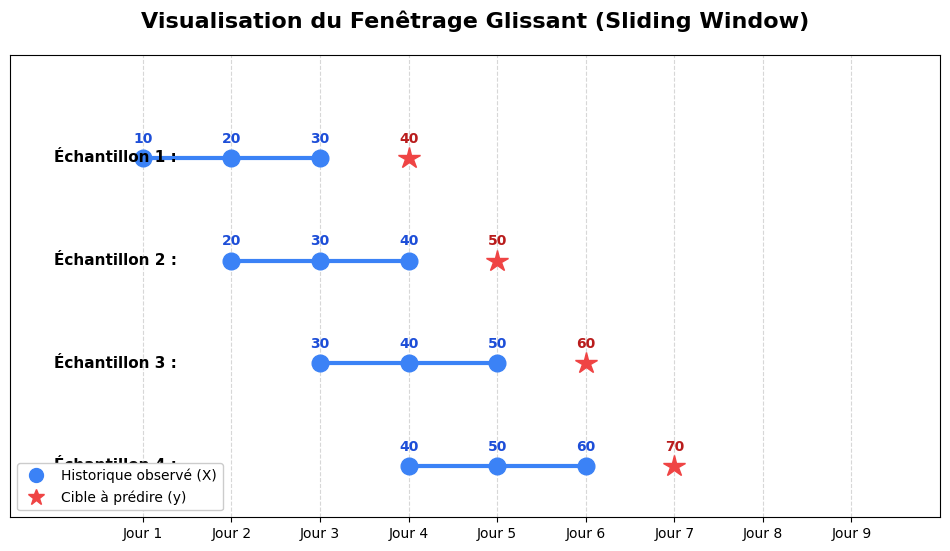

💡 Analyse de la figure:
Observez comment la fenêtre glisse d'un pas vers la droite à chaque ligne.
Ce processus transforme notre axe temporel unique en de multiples exemples d'apprentissage (Batch_size).
Le RNN va lire la ligne 1, mettre à jour ses poids, puis lire la ligne 2, etc.


In [ ]:
import matplotlib.pyplot as plt

# Série et paramètres (rappel)
serie_brute = [10, 20, 30, 40, 50, 60, 70, 80, 90]
TIME_STEPS = 3

plt.figure(figsize=(12, 6))

# On ne dessine que les 4 premières fenêtres pour la clarté pédagogique
nb_fenetres_a_dessiner = 4

for i in range(nb_fenetres_a_dessiner):
    y_pos = nb_fenetres_a_dessiner - i # Pour dessiner de haut en bas

    # 1. Dessiner les points d'entrée X (Historique)
    x_indices = range(i, i + TIME_STEPS)
    x_valeurs = serie_brute[i : i + TIME_STEPS]

    plt.plot(x_indices, [y_pos]*TIME_STEPS, marker='o', markersize=12, color='#3b82f6', linewidth=3)

    # Ajouter le texte des valeurs X
    for j, val in zip(x_indices, x_valeurs):
        plt.text(j, y_pos + 0.15, str(val), ha='center', color='#1d4ed8', fontweight='bold')

    # 2. Dessiner le point cible y (Prédiction)
    y_indice = i + TIME_STEPS
    y_valeur = serie_brute[y_indice]

    plt.plot(y_indice, y_pos, marker='*', markersize=16, color='#ef4444')

    # Ajouter le texte de la valeur y
    plt.text(y_indice, y_pos + 0.15, str(y_valeur), ha='center', color='#b91c1c', fontweight='bold')

    # 3. Label de la fenêtre
    plt.text(-1, y_pos, f"Échantillon {i+1} :", va='center', fontweight='bold', fontsize=11)

# Esthétique du graphique
plt.title("Visualisation du Fenêtrage Glissant (Sliding Window)", fontsize=16, fontweight='bold', pad=20)
plt.yticks([]) # On cache l'axe Y qui ne sert qu'à espacer les lignes
plt.xticks(range(len(serie_brute)), [f"Jour {j+1}" for j in range(len(serie_brute))], fontsize=10)
plt.xlim(-1.5, len(serie_brute))
plt.ylim(0.5, nb_fenetres_a_dessiner + 1)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Légende personnalisée
plt.plot([], [], marker='o', color='#3b82f6', label='Historique observé (X)', linestyle='None', markersize=10)
plt.plot([], [], marker='*', color='#ef4444', label='Cible à prédire (y)', linestyle='None', markersize=12)
plt.legend(loc='lower left', framealpha=1)

plt.show()

print("💡 Analyse de la figure:")
print("Observez comment la fenêtre glisse d'un pas vers la droite à chaque ligne.")
print("Ce processus transforme notre axe temporel unique en de multiples exemples d'apprentissage (Batch_size).")
print("Le RNN va lire la ligne 1, mettre à jour ses poids, puis lire la ligne 2, etc.")

## 🎬 Acte 3 : Le Premier Succès avec Keras (L'Onde Sinusoïdale)


Maintenant que nous maîtrisons la théorie mathématique et le redoutable formatage du tenseur 3D, il est temps de faire appel à la cavalerie lourde : **Keras**.


Nous allons demander à un modèle `SimpleRNN` d'apprendre la dynamique d'une vague continue (une fonction Sinus).



### **Pourquoi la fonction Sinus ?**

1. **Zéro Bruit :** C'est un signal mathématique pur. Si le réseau échoue, nous saurons que le problème vient de l'architecture, pas de la qualité des données.


2. **Déjà normalisée :** La fonction sinus oscille naturellement entre -1 et 1. C'est parfait pour notre fonction d'activation $\tanh$ qui adore cette plage de valeurs !

Pas besoin de `MinMaxScaler` pour cette expérience.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Génération du signal temporel (L'Onde Sinusoïdale)
# ---------------------------------------------------------
# On crée 1000 points de temps
temps = np.linspace(0, 50, 1000)
# On génère la vague
serie_onde = np.sin(temps)

# ---------------------------------------------------------
# 2. Le Fenêtrage (Sliding Window) et Tenseur 3D
# ---------------------------------------------------------
TIME_STEPS = 10  # Le réseau regardera 10 pas en arrière pour deviner le 11ème

def preparer_donnees_keras(serie, time_steps):
    X, y = [], []
    for i in range(len(serie) - time_steps):
        X.append(serie[i : i + time_steps])
        y.append(serie[i + time_steps])

    X = np.array(X)
    y = np.array(y)
    # LE FAMEUX RESHAPE EN 3D : (batch_size, time_steps, features)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))
    return X, y

X_keras, y_keras = preparer_donnees_keras(serie_onde, TIME_STEPS)

# ---------------------------------------------------------
# 3. Séparation Entraînement / Test (Train/Test Split)
# ---------------------------------------------------------
# On garde les 800 premiers points pour l'apprentissage, et on testera sur les 200 derniers
split = 800
X_train, X_test = X_keras[:split], X_keras[split:]
y_train, y_test = y_keras[:split], y_keras[split:]

print("✅ Données prêtes pour Keras !")
print(f"Format de X_train (Le Tenseur 3D) : {X_train.shape}")
print(f"Format de y_train (Le Vecteur Cible) : {y_train.shape}")

✅ Données prêtes pour Keras !
Format de X_train (Le Tenseur 3D) : (800, 10, 1)
Format de y_train (Le Vecteur Cible) : (800,)


###**L'Anatomie de notre Modèle Keras**

Nous allons construire un modèle séquentiel avec deux couches :


1. **La Couche `SimpleRNN` :** C'est le cerveau temporel. On lui donne `16` neurones (la taille de son état caché $h_t$).
    * ***Le piège classique :*** Dans `input_shape`, on ne renseigne **que** les dimensions temporelles et les variables `(time_steps, features)`. Keras gère la dimension `batch_size` automatiquement en arrière-plan !


2. **La Couche `Dense` :** Le RNN produit un vecteur caché de 16 valeurs. Notre objectif est de prédire une seule valeur (la position de la vague au temps $t+1$). La couche Dense agit comme un entonnoir de régression : elle condense ces 16 valeurs en 1 seul chiffre continu.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# 1. Construction du Modèle
model_sinus = Sequential([
    # La couche récurrente lit la séquence de 10 jours
    SimpleRNN(units=16, activation='tanh', input_shape=(TIME_STEPS, 1)),

    # La couche de sortie (1 seul neurone car on prédit 1 seule valeur continue)
    Dense(units=1)
])

# 2. Compilation
# loss='mse' (Erreur Quadratique Moyenne) car c'est un problème de régression
# optimizer='adam' car c'est le standard de l'industrie (rapide et adaptatif)
model_sinus.compile(loss='mse', optimizer='adam')

model_sinus.summary()

# 3. Entraînement (Apprentissage)
print("\n⏳ Début de l'entraînement du réseau...")
historique = model_sinus.fit(
    X_train, y_train,
    epochs=20,          # On parcourt le dataset 20 fois
    batch_size=32,      # On met à jour les poids par paquets de 32 fenêtres
    validation_data=(X_test, y_test),
    verbose=1
)
print("✅ Entraînement terminé !")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 16)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)


⏳ Début de l'entraînement du réseau...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.6078 - val_loss: 0.1238
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0867 - val_loss: 0.0314
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0226 - val_loss: 0.0101
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0088 - val_loss: 0.0076
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0074 - val_loss: 0.0064
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0058 - val_loss: 0.0054
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0053 - val_loss: 0.0047
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0044 - val_loss: 0.0042
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0040 - val_loss: 0.0037
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0038 - val_loss: 0.0032
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 12/20
25/25 ━━━━━━━━━━━

###**Le Test Visuel (L'heure de vérité)**

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


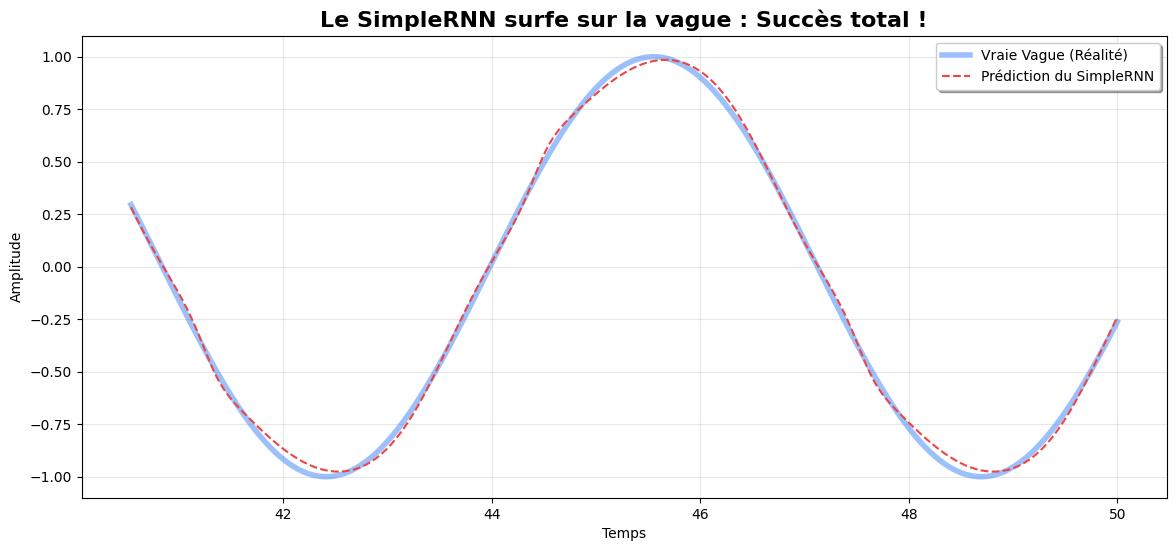

🎯 Analyse Visuelle :
Les pointillés rouges recouvrent parfaitement la ligne bleue. Le modèle a parfaitement appris la dynamique temporelle.


In [ ]:
# 1. On demande au modèle de prédire la vague sur le jeu de test (qu'il n'a pas vu pendant l'entraînement)
predictions = model_sinus.predict(X_test)

# 2. Visualisation Pédagogique
plt.figure(figsize=(14, 6))

# On génère l'axe des temps correspondant au jeu de test
temps_test = temps[split + TIME_STEPS:]

# On trace la vraie vague (Épaisse et claire)
plt.plot(temps_test, y_test, label="Vraie Vague (Réalité)", color='#3b82f6', linewidth=4, alpha=0.5)

# On trace la prédiction du modèle (En pointillés rouges)
plt.plot(temps_test, predictions, label="Prédiction du SimpleRNN", color='#ef4444', linestyle='--')

plt.title("Le SimpleRNN surfe sur la vague : Succès total !", fontsize=16, fontweight='bold')
plt.xlabel("Temps")
plt.ylabel("Amplitude")
plt.legend(loc="upper right", shadow=True)
plt.grid(True, alpha=0.3)
plt.show()

print("🎯 Analyse Visuelle :")
print("Les pointillés rouges recouvrent parfaitement la ligne bleue. Le modèle a parfaitement appris la dynamique temporelle.")

### **🏆 Victoire... mais attention au mirage !**

Ce résultat est spectaculaire. En quelques secondes, le réseau a modélisé une équation différentielle complexe (la dynamique d'un sinus) sans qu'on lui fournisse la moindre formule mathématique. Il a "appris" la physique de la vague en observant ses états passés.


**Cependant, posez-vous cette question :** Ici, nous regardions une fenêtre de 10 pas en arrière (`TIME_STEPS = 10`). Pour savoir si la vague monte ou descend, 10 pas de temps récents suffisent amplement. L'information cruciale est **très proche** du moment de la prédiction.


Que se passerait-il si l'indice permettant de prédire le jour 100 n'était pas caché dans les 10 derniers jours, mais se trouvait **au jour 1** ? Le SimpleRNN s'en souviendrait-il ?


## **🎬 Acte 4 : Le Crash Test (La Preuve du Gradient Évanescent)**

Jusqu'à présent, le SimpleRNN a réussi à prédire une vague courte, car l'information était toujours "récente". Mais que se passe-t-il sur une série temporelle réelle qui possède une **mémoire à long terme** ?

Imaginons un phénomène naturel ou économique (comme le réapprovisionnement de stocks) qui possède un cycle strict : **la valeur d'aujourd'hui dépend énormément de ce qui s'est passé il y a exactement 60 jours.**

Mathématiquement, c'est ce qu'on appelle un processus Auto-Régressif à long retard : $y_t = 0.8 \times y_{t-60} + \text{Bruit}_t$.

Nous allons générer cette série temporelle **unique et continue**, la découper avec notre méthode de fenêtrage (Sliding Window), et demander au réseau de prédire l'avenir.

###**Création du Dataset Piège**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Génération de la Série Temporelle Continue (1D)
# ---------------------------------------------------------
np.random.seed(42)
LONGUEUR_SERIE = 2000
RETARD = 60  # La saisonnalité : l'écho se fait sur 60 jours

# On commence par un bruit de fond pur (ventes aléatoires)
serie_reelle = np.random.normal(loc=0, scale=1, size=LONGUEUR_SERIE)

# On applique la règle du temps : Le jour t est un "écho" du jour t-60
for t in range(RETARD, LONGUEUR_SERIE):
    serie_reelle[t] = 0.8 * serie_reelle[t - RETARD] + np.random.normal(0, 0.5)

print("✅ Série temporelle continue générée !")

# ---------------------------------------------------------
# 2. Le Fenêtrage (Sliding Window) - Retour à la méthode de l'Acte 2
# ---------------------------------------------------------
TIME_STEPS = 60  # On donne au réseau une fenêtre de 60 jours

def creer_dataset_3D(serie, time_steps):
    X, y = [], []
    for i in range(len(serie) - time_steps):
        X.append(serie[i : i + time_steps])
        y.append(serie[i + time_steps]) # La cible est le jour t+1
    return np.reshape(np.array(X), (-1, time_steps, 1)), np.array(y)

X_seq, y_seq = creer_dataset_3D(serie_reelle, TIME_STEPS)

# Split Train/Test
split = 1500
X_train_r, X_test_r = X_seq[:split], X_seq[split:]
y_train_r, y_test_r = y_seq[:split], y_seq[split:]

print(f"Format des données d'entraînement : X={X_train_r.shape}, y={y_train_r.shape}")

✅ Série temporelle continue générée !
Format des données d'entraînement : X=(1500, 60, 1), y=(1500,)


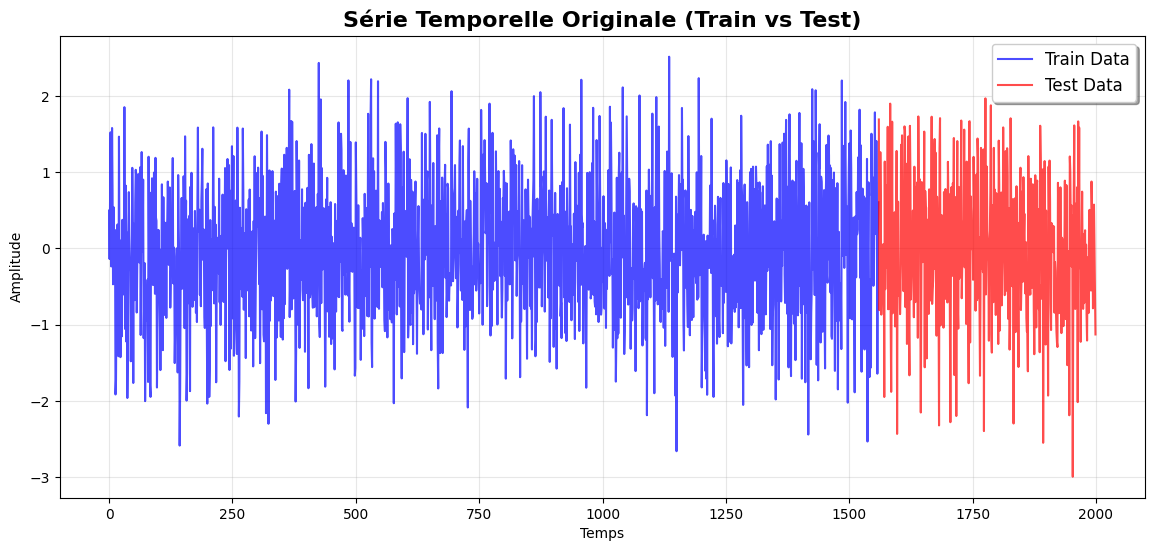

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(serie_reelle[:split + RETARD], label='Train Data', color='blue', alpha=0.7)
plt.plot(range(split + RETARD, len(serie_reelle)), serie_reelle[split + RETARD:], label='Test Data', color='red', alpha=0.7)
plt.title("Série Temporelle Originale (Train vs Test)", fontsize=16, fontweight='bold')
plt.xlabel("Temps")
plt.ylabel("Amplitude")
plt.legend(shadow=True, fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### Analyse du Piège Temporel

Regardons comment notre fenêtrage a préparé les données pour prédire la cible $y$.
Le réseau reçoit une fenêtre de 60 jours (de l'index 0 à 59).
* L'information la plus récente est à l'index **59** (hier).
* L'information la plus ancienne est à l'index **0** (il y a 60 jours).

**Le drame :** À cause de la règle mathématique avec laquelle nous avons généré cette série ($y_t = 0.8 \times y_{t-60}$), la \textbf{seule} valeur vraiment utile pour prédire demain se trouve à l'**index 0** de la fenêtre ! Les 59 autres jours qui suivent ne sont que des distractions (du bruit).

Le réseau va lire la fenêtre de gauche à droite. Pour utiliser l'index 0, il va devoir faire survivre cette information à travers 60 multiplications matricielles jusqu'à la fin de la fenêtre.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


⏳ Entraînement du réseau sur la série temporelle... (Attention au crash)
✅ Entraînement terminé.
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


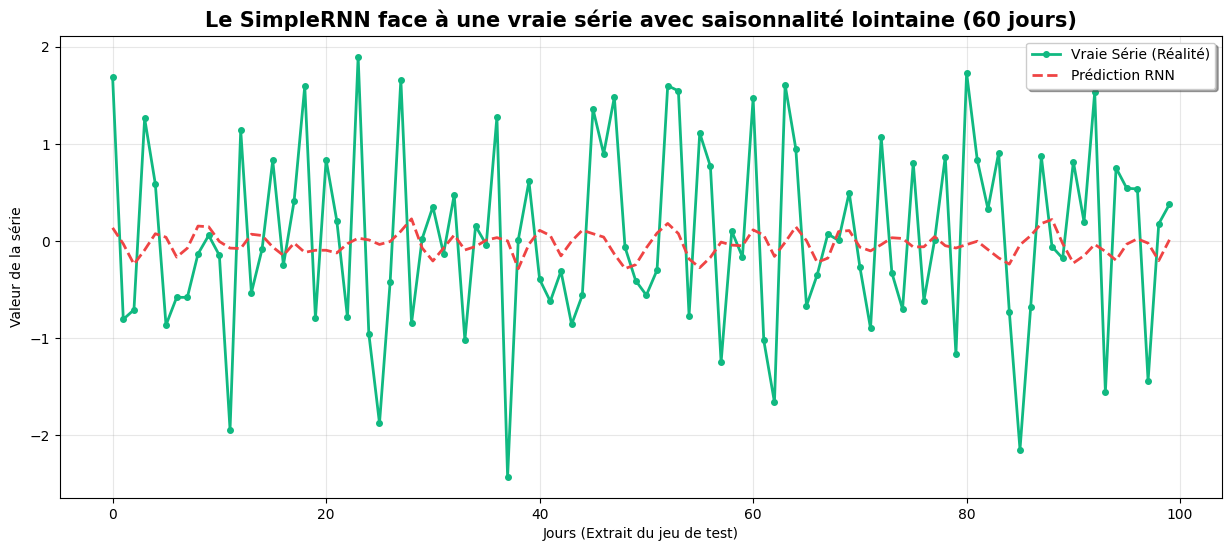


🚨 RÉSULTAT DU CRASH TEST : L'AMNÉSIE EN ACTION
Observez le graphique : La vraie série (en vert) fait des pics et des creux marqués (les échos d'il y a 60 jours).
La prédiction du RNN (en rouge) est une ligne molle et presque plate, qui stagne près de 0.
Conclusion : Le réseau est incapable de repérer les pics car il a oublié la valeur du Jour 0 à cause du Gradient Évanescent. Il se contente de prédire la moyenne molle de la série.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# On désactive l'initialisation orthogonale de Keras pour voir la vraie limite mathématique
model_reel = Sequential([
    SimpleRNN(32, activation='tanh', input_shape=(TIME_STEPS, 1), recurrent_initializer='random_normal'),
    Dense(1)
])

model_reel.compile(loss='mse', optimizer='adam')

print("⏳ Entraînement du réseau sur la série temporelle... (Attention au crash)")
historique = model_reel.fit(X_train_r, y_train_r, epochs=15, batch_size=64, validation_split=0.1, verbose=0)
print("✅ Entraînement terminé.")

# -- VERDICT VISUEL --
predictions_r = model_reel.predict(X_test_r)

plt.figure(figsize=(15, 6))
# On affiche un extrait de 100 jours du jeu de test pour bien voir les pics
extrait = 100
temps_axe = np.arange(extrait)

plt.plot(temps_axe, y_test_r[:extrait], label="Vraie Série (Réalité)", color='#10b981', linewidth=2, marker='o', markersize=4)
plt.plot(temps_axe, predictions_r[:extrait], label="Prédiction RNN", color='#ef4444', linestyle='dashed', linewidth=2)

plt.title("Le SimpleRNN face à une vraie série avec saisonnalité lointaine (60 jours)", fontsize=15, fontweight='bold')
plt.xlabel("Jours (Extrait du jeu de test)")
plt.ylabel("Valeur de la série")
plt.legend(shadow=True)
plt.grid(True, alpha=0.3)
plt.show()

print("\n🚨 RÉSULTAT DU CRASH TEST : L'AMNÉSIE EN ACTION")
print("Observez le graphique : La vraie série (en vert) fait des pics et des creux marqués (les échos d'il y a 60 jours).")
print("La prédiction du RNN (en rouge) est une ligne molle et presque plate, qui stagne près de 0.")
print("Conclusion : Le réseau est incapable de repérer les pics car il a oublié la valeur du Jour 0 à cause du Gradient Évanescent. Il se contente de prédire la moyenne molle de la série.")

## **🎬 Acte 5 : L'Avènement du Héros (La Revanche du LSTM)**

Le SimpleRNN a échoué car il a oublié que le secret de la prédiction se trouvait au Jour 0 (il y a 60 jours). Son architecture l'a obligé à multiplier cette information 60 fois, la diluant jusqu'à la faire disparaître.

C'est ici qu'intervient le **LSTM (Long Short-Term Memory)**.
Grâce à son **Cell State** (une autoroute de l'information qui traverse le réseau de bout en bout), l'information du Jour 0 peut glisser jusqu'au Jour 60 en étant simplement régulée par des "valves" (les Portes), sans subir de multiplications destructrices.

Voyons si la pratique confirme cette belle promesse théorique sur nos données !

In [ ]:
from tensorflow.keras.layers import LSTM

# 1. Création du modèle LSTM
# On garde exactement la même "taille de cerveau" (32 neurones) pour que le combat soit équitable
model_heros = Sequential([
    LSTM(32, input_shape=(TIME_STEPS, 1)), # Keras gère toute la complexité des portes en interne !
    Dense(1)
])

model_heros.compile(loss='mse', optimizer='adam')

print("🦸‍♂️ Entraînement du LSTM sur la même série temporelle...")
# L'entraînement d'un LSTM est un peu plus lent (car il y a 4 fois plus de calculs internes avec les portes)
historique_lstm = model_heros.fit(
    X_train_r, y_train_r,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)
print("✅ Entraînement terminé.")

🦸‍♂️ Entraînement du LSTM sur la même série temporelle...
Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.6987 - val_loss: 1.0207
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.7295 - val_loss: 1.0217
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.6854 - val_loss: 1.0207
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.7088 - val_loss: 1.0142
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.7254 - val_loss: 1.0050
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.7041 - val_loss: 0.9876
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.7334 - val_loss: 0.9791
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.6817 - val_loss: 0.9738
Epoch 9/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.6909 - val_loss: 0.9593
Epoch 10/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.7056 - val_loss: 0.9505
Epoch 11/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.7091 - val_loss: 0.9579
Epoch

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


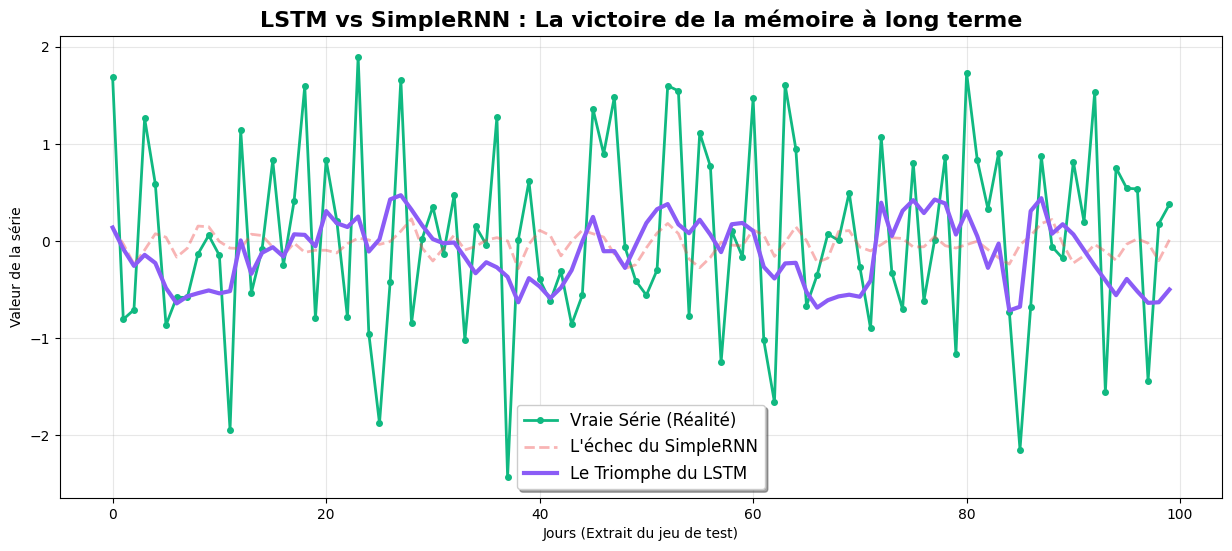


🏆 ANALYSE DE LA VICTOIRE (ET DE SES LIMITES) :
1. LA MÉMOIRE SAUVÉE : Regardez la courbe violette (le LSTM). Contrairement au RNN (en rouge pâle) qui traçait une ligne morte, le LSTM monte et descend en rythme avec les vrais pics de la réalité !
   -> Il a réussi l'exploit de conserver l'information du 'Jour 0' pendant 60 étapes grâce à son Cell State et ses Portes (Gates).

2. L'ERREUR IRRÉDUCTIBLE : Vous remarquerez que le LSTM n'atteint pas l'amplitude parfaite des pics verts. Pourquoi ?
   -> Parce que notre vraie série contient un bruit aléatoire au jour J. Le réseau a parfaitement appris l'écho du passé, mais personne ne peut prédire le hasard pur. C'est ce qu'on appelle la limite de l'erreur irréductible en Machine Learning !


In [ ]:
# -- VERDICT VISUEL DU LSTM --
predictions_lstm = model_heros.predict(X_test_r)

plt.figure(figsize=(15, 6))

plt.plot(temps_axe, y_test_r[:extrait], label="Vraie Série (Réalité)", color='#10b981', linewidth=2, marker='o', markersize=4)
plt.plot(temps_axe, predictions_r[:extrait], label="L'échec du SimpleRNN", color='#ef4444', linestyle='dashed', linewidth=2, alpha=0.4)
plt.plot(temps_axe, predictions_lstm[:extrait], label="Le Triomphe du LSTM", color='#8b5cf6', linewidth=3)

plt.title("LSTM vs SimpleRNN : La victoire de la mémoire à long terme", fontsize=16, fontweight='bold')
plt.xlabel("Jours (Extrait du jeu de test)")
plt.ylabel("Valeur de la série")
plt.legend(shadow=True, fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print("\n🏆 ANALYSE DE LA VICTOIRE (ET DE SES LIMITES) :")
print("1. LA MÉMOIRE SAUVÉE : Regardez la courbe violette (le LSTM). Contrairement au RNN (en rouge pâle) qui traçait une ligne morte, le LSTM monte et descend en rythme avec les vrais pics de la réalité !")
print("   -> Il a réussi l'exploit de conserver l'information du 'Jour 0' pendant 60 étapes grâce à son Cell State et ses Portes (Gates).")
print("\n2. L'ERREUR IRRÉDUCTIBLE : Vous remarquerez que le LSTM n'atteint pas l'amplitude parfaite des pics verts. Pourquoi ?")
print("   -> Parce que notre vraie série contient un bruit aléatoire au jour J. Le réseau a parfaitement appris l'écho du passé, mais personne ne peut prédire le hasard pur. C'est ce qu'on appelle la limite de l'erreur irréductible en Machine Learning !")

## **🎬 Acte 6 : Le Challenger (Le réseau GRU)**

Le LSTM a brillamment sauvé notre prédiction, mais il a un défaut : il est "lourd". Avec ses 3 portes (Input, Forget, Output) et ses deux mémoires séparées ($C_t$ et $h_t$), il demande beaucoup de calculs mathématiques à la machine.

En 2014, des chercheurs ont inventé le **GRU (Gated Recurrent Unit)**. Son but ? Simplifier le LSTM pour accélérer l'entraînement, tout en gardant une protection contre le Gradient Évanescent.
* Il fusionne la mémoire à long terme et à court terme en un seul vecteur.
* Il réduit le nombre de portes.

[Image of LSTM cell architecture compared side-by-side with GRU cell architecture]

Testons-le sur notre dataset redoutable de 60 jours pour voir s'il fait le poids face au champion LSTM !

In [ ]:
from tensorflow.keras.layers import GRU
import time

# 1. Création du modèle GRU
# Toujours 32 neurones pour une comparaison parfaitement équitable
model_gru = Sequential([
    GRU(32, input_shape=(TIME_STEPS, 1)),
    Dense(1)
])

model_gru.compile(loss='mse', optimizer='adam')

print("🚀 Entraînement du challenger GRU...")
# On ajoute un petit chronomètre pour vérifier s'il est vraiment plus rapide
debut = time.time()

historique_gru = model_gru.fit(
    X_train_r, y_train_r,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

fin = time.time()
print(f"✅ Entraînement terminé en {fin - debut:.2f} secondes.")

🚀 Entraînement du challenger GRU...
Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.7583 - val_loss: 1.0141
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.7025 - val_loss: 1.0204
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.6918 - val_loss: 1.0188
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.6839 - val_loss: 1.0161
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.7030 - val_loss: 1.0159
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.6843 - val_loss: 1.0153
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.7224 - val_loss: 1.0075
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.7214 - val_loss: 1.0090
Epoch 9/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.6780 - val_loss: 1.0128
Epoch 10/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.6751 - val_loss: 1.0054
Epoch 11/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.7344 - val_loss: 1.0028
Epoch 12/15
22/22 ━━━━━━━━━

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


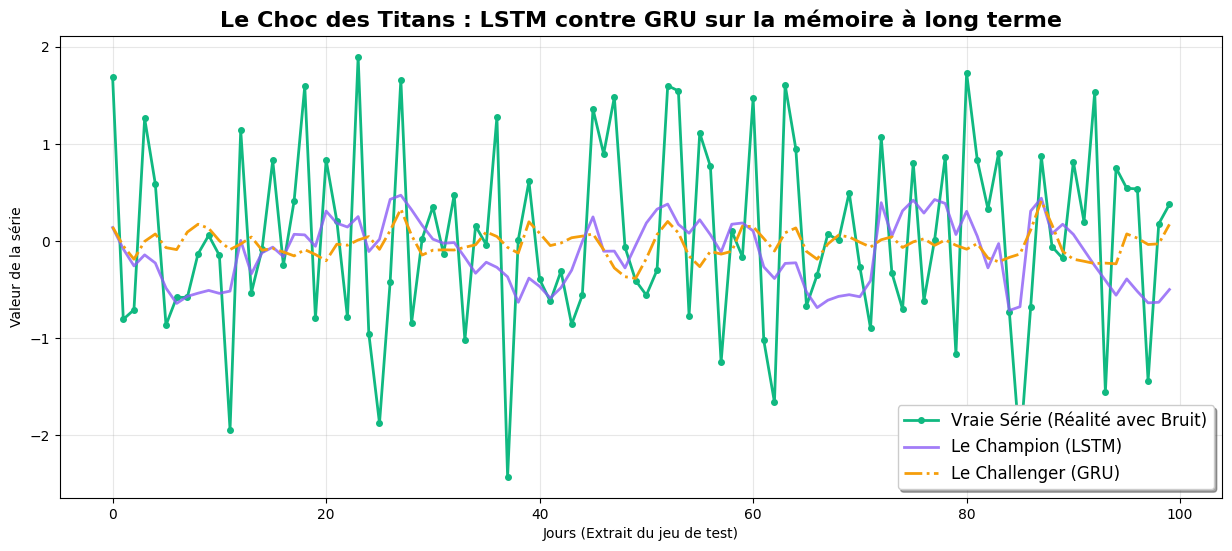


🥊 RÉSULTAT DU MATCH : VICTOIRE DU LSTM !
1. PERFORMANCES : Regardez attentivement les courbes. Le GRU (orange) a échoué là où le LSTM (violet) a réussi ! La ligne du GRU est beaucoup plus plate et rate complètement l'amplitude des pics verts.
   -> L'Explication : Le GRU ne possède pas de 'Cell State' (l'autoroute) isolé. Sa mémoire (h_t) est totalement exposée au monde extérieur et au bruit à chaque nouveau jour. Face à 60 jours de perturbations intenses, le signal a fini par fuiter et s'effacer.
2. EFFICACITÉ : Le GRU conserve tout de même un avantage (regardez votre chronomètre) : il s'entraîne plus vite que le LSTM car son architecture allégée (seulement 2 portes) nécessite moins de calculs mathématiques.

💡 Conclusion pour le Data Scientist :
Ce test est une leçon magistrale d'architecture. Le GRU est un excellent modèle, rapide et performant pour des dépendances modérées. Mais face à une 'mémoire à très long terme' noyée dans un bruit intense, le LSTM reste le Roi incontesté grâ

In [ ]:
# -- VERDICT VISUEL DU GRU VS LSTM --
predictions_gru = model_gru.predict(X_test_r)

plt.figure(figsize=(15, 6))

# La réalité
plt.plot(temps_axe, y_test_r[:extrait], label="Vraie Série (Réalité avec Bruit)", color='#10b981', linewidth=2, marker='o', markersize=4)

# Les deux champions
plt.plot(temps_axe, predictions_lstm[:extrait], label="Le Champion (LSTM)", color='#8b5cf6', linewidth=2, alpha=0.8)
plt.plot(temps_axe, predictions_gru[:extrait], label="Le Challenger (GRU)", color='#f59e0b', linewidth=2, linestyle='-.')

plt.title("Le Choc des Titans : LSTM contre GRU sur la mémoire à long terme", fontsize=16, fontweight='bold')
plt.xlabel("Jours (Extrait du jeu de test)")
plt.ylabel("Valeur de la série")
plt.legend(shadow=True, fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print("\n🥊 RÉSULTAT DU MATCH : VICTOIRE DU LSTM !")
print("1. PERFORMANCES : Regardez attentivement les courbes. Le GRU (orange) a échoué là où le LSTM (violet) a réussi ! La ligne du GRU est beaucoup plus plate et rate complètement l'amplitude des pics verts.")
print("   -> L'Explication : Le GRU ne possède pas de 'Cell State' (l'autoroute) isolé. Sa mémoire (h_t) est totalement exposée au monde extérieur et au bruit à chaque nouveau jour. Face à 60 jours de perturbations intenses, le signal a fini par fuiter et s'effacer.")
print("2. EFFICACITÉ : Le GRU conserve tout de même un avantage (regardez votre chronomètre) : il s'entraîne plus vite que le LSTM car son architecture allégée (seulement 2 portes) nécessite moins de calculs mathématiques.")
print("\n💡 Conclusion pour le Data Scientist :")
print("Ce test est une leçon magistrale d'architecture. Le GRU est un excellent modèle, rapide et performant pour des dépendances modérées. Mais face à une 'mémoire à très long terme' noyée dans un bruit intense, le LSTM reste le Roi incontesté grâce à la protection blindée de son Cell State !")

###**Ajouter de la convolution**

🚀 Création de l'architecture Hybride CNN-LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Entraînement du modèle Hybride terminé en 12.64 secondes.
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


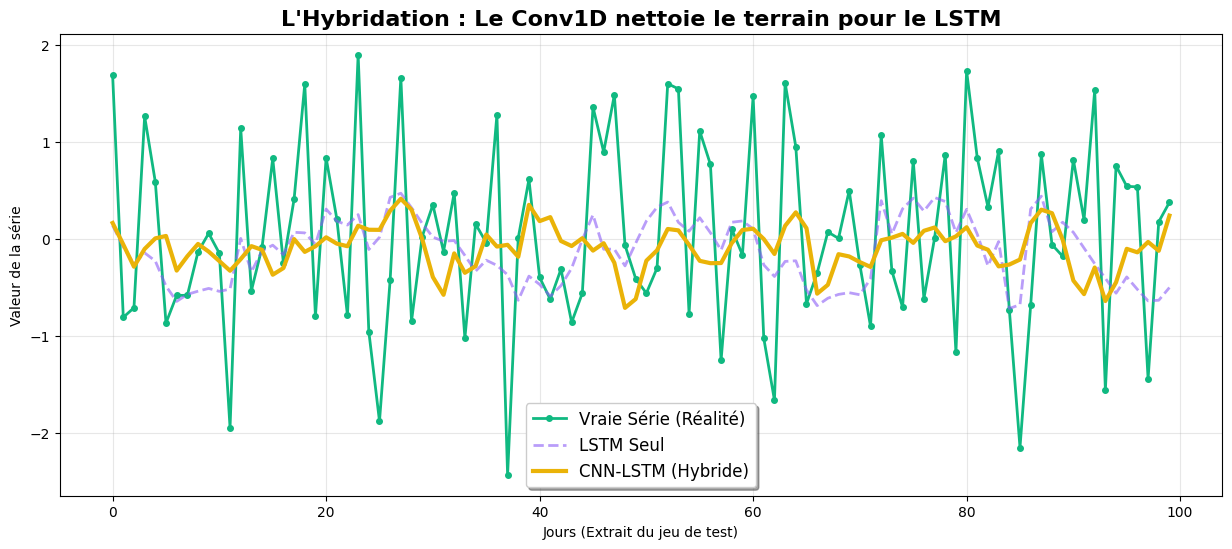


🌟 ANALYSE DE L'HYBRIDATION :
1. SYNERGIE : La courbe jaune (CNN-LSTM) suit la réalité de manière souvent plus lisse et robuste. Le Conv1D a agi comme un excellent nettoyeur de bruit.
2. VITESSE : Regardez les temps d'entraînement. En compressant la séquence avec le MaxPooling, le LSTM a fait beaucoup moins de calculs. Le modèle hybride est souvent plus rapide ET plus performant !


In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense
from tensorflow.keras.models import Sequential
import time

# ---------------------------------------------------------
# 🎬 Acte 7 : L'Arme Ultime (Conv1D + LSTM)
# ---------------------------------------------------------
print("🚀 Création de l'architecture Hybride CNN-LSTM...")

model_hybride = Sequential([
    # 1. Le Feature Extractor (Vision Locale)
    # On regarde les jours par paquets de 3 (kernel_size=3)
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(TIME_STEPS, 1)),

    # 2. Le Compresseur
    # On divise la longueur de la séquence par 2
    MaxPooling1D(pool_size=2),

    # 3. Le Cerveau Temporel (Mémoire à long terme)
    # Le LSTM ne reçoit plus 60 jours, mais beaucoup moins, et sans le bruit !
    LSTM(32),

    # 4. La Prédiction finale
    Dense(1)
])

model_hybride.compile(loss='mse', optimizer='adam')

# Entraînement
debut_hybride = time.time()
historique_hybride = model_hybride.fit(
    X_train_r, y_train_r,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=0 # On cache les logs
)
fin_hybride = time.time()

print(f"✅ Entraînement du modèle Hybride terminé en {fin_hybride - debut_hybride:.2f} secondes.")

# -- VERDICT VISUEL --
predictions_hybride = model_hybride.predict(X_test_r)

plt.figure(figsize=(15, 6))

plt.plot(temps_axe, y_test_r[:extrait], label="Vraie Série (Réalité)", color='#10b981', linewidth=2, marker='o', markersize=4)
plt.plot(temps_axe, predictions_lstm[:extrait], label="LSTM Seul", color='#8b5cf6', linestyle='dashed', linewidth=2, alpha=0.6)
plt.plot(temps_axe, predictions_hybride[:extrait], label="CNN-LSTM (Hybride)", color='#eab308', linewidth=3)

plt.title("L'Hybridation : Le Conv1D nettoie le terrain pour le LSTM", fontsize=16, fontweight='bold')
plt.xlabel("Jours (Extrait du jeu de test)")
plt.ylabel("Valeur de la série")
plt.legend(shadow=True, fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print("\n🌟 ANALYSE DE L'HYBRIDATION :")
print("1. SYNERGIE : La courbe jaune (CNN-LSTM) suit la réalité de manière souvent plus lisse et robuste. Le Conv1D a agi comme un excellent nettoyeur de bruit.")
print("2. VITESSE : Regardez les temps d'entraînement. En compressant la séquence avec le MaxPooling, le LSTM a fait beaucoup moins de calculs. Le modèle hybride est souvent plus rapide ET plus performant !")

## 🗺️ Interlude : La Carte du Monde des Séries Temporelles

Avant de complexifier notre réseau avec de multiples variables, prenons un peu de recul. Nous venons de voir comment construire un LSTM et un CNN-1D. Ce sont des outils surpuissants. Mais sont-ils toujours la meilleure solution ?

Dans la vraie vie d'un Data Scientist ou d'un chercheur, l'Intelligence Artificielle n'est qu'une famille d'outils parmi d'autres. Voici la "boîte à outils" de l'état de l'art (SOTA) en séries temporelles :

### 1. La base statistique (Rapide et explicable)
* **Les modèles :** ARIMA, SARIMAX, Lissage Exponentiel.
* **Quand l'utiliser ?** Quand vous avez peu de données (moins de 1000 points), et une série très propre et mathématique. C'est le standard historique.

### 2. Les modèles Additifs & le Machine Learning (Le couteau suisse de l'entreprise)
* **Les modèles :** **Prophet** (créé par Meta/Facebook), XGBoost, LightGBM.
* **Pourquoi Prophet est si célèbre ?** Prophet n'est pas un réseau de neurones. Il décompose mathématiquement la courbe (Tendance + Saisonnalité + Jours Fériés). Il est devenu le standard en entreprise car il gère tout seul les données manquantes, les valeurs aberrantes (outliers), et s'entraîne en 2 secondes. Pour prévoir les ventes d'un magasin, on commence TOUJOURS par tester Prophet.

### 3. Le Deep Learning Séquentiel (L'artillerie lourde)
* **Les modèles :** **CNN-1D, LSTM, GRU** (Ce que nous venons de coder !).
* **Quand l'utiliser ?** Quand la série est complexe, très longue (haute fréquence comme le son ou l'IoT), très bruitée, et qu'il y a de multiples variables qui interagissent de manière non-linéaire.

### 4. Le véritable État de l'Art (SOTA) aujourd'hui
* **Les modèles :** Temporal Fusion Transformers (TFT), N-BEATS, PatchTST, TimeGPT.
* **L'avenir :** Le monde des séries temporelles est en train de subir la même révolution que le texte avec ChatGPT. L'architecture "Transformer" commence à remplacer les LSTM sur les problèmes massifs.

**💡 La Règle d'Or :** Ne sortez pas un bazooka (LSTM) pour écraser une mouche. Testez toujours un modèle simple (ARIMA ou Prophet) en premier. Il servira de *Baseline* (point de référence). Si votre LSTM à la fin de la journée ne bat pas Prophet, alors gardez Prophet !

## 🎬 Acte 8 : Le Choc des Cultures (Deep Learning vs Prophet)

Nous avons passé des heures à formater nos données en Tenseurs 3D `(batch_size, time_steps, features)` pour nourrir notre LSTM. C'est l'approche "Deep Learning".

Mais que se passe-t-il si nous donnons la même série temporelle à **Prophet** (le modèle open-source de Meta/Facebook), qui est le standard de l'industrie pour les prévisions rapides ?



**La philosophie de Prophet :** Il se moque des fenêtres glissantes (Sliding Windows). Il ne veut qu'un tableau (DataFrame Pandas) avec deux colonnes :
* `ds` : La date exacte.
* `y` : La valeur à prédire.

Mettons notre LSTM Hybride (Conv1D) au défi face à Prophet !

In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# 1. Prophet exige des dates ! Nous allons inventer un calendrier artificiel pour notre série temporelle.
dates = pd.date_range(start='2020-01-01', periods=LONGUEUR_SERIE, freq='D')

# 2. Création du DataFrame Pandas exigé par Prophet
df_complet = pd.DataFrame({
    'ds': dates,
    'y': serie_reelle # Notre fameuse série avec la saisonnalité de 60 jours
})

# 3. Le même Split (Train/Test) que pour nos réseaux de neurones
split = 1500
df_train = df_complet.iloc[:split]
df_test = df_complet.iloc[split:]

print("✅ Données formatées pour Prophet ! Regardez la simplicité :")
print(df_train.head())

✅ Données formatées pour Prophet ! Regardez la simplicité :
          ds         y
0 2020-01-01  0.496714
1 2020-01-02 -0.138264
2 2020-01-03  0.647689
3 2020-01-04  1.523030
4 2020-01-05 -0.234153


In [ ]:
# 1. Initialisation de Prophet
# On lui précise explicitement de chercher une saisonnalité, car notre série est complexe
modele_prophet = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=False)

# On force Prophet à chercher un cycle de 60 jours (notre piège !)
modele_prophet.add_seasonality(name='cycle_60j', period=60, fourier_order=5)

# 2. Entraînement (Ajustement de la courbe)
print("⏳ Entraînement de Prophet (Statistiques Additives)...")
modele_prophet.fit(df_train)
print("✅ Entraînement terminé en un clin d'œil !")

# 3. Prédiction
# On prépare un DataFrame avec les dates du futur (notre jeu de test)
futur = df_test[['ds']]
predictions_prophet_brutes = modele_prophet.predict(futur)

# On extrait juste la colonne 'yhat' (la prédiction)
predictions_prophet = predictions_prophet_brutes['yhat'].values

⏳ Entraînement de Prophet (Statistiques Additives)...
✅ Entraînement terminé en un clin d'œil !


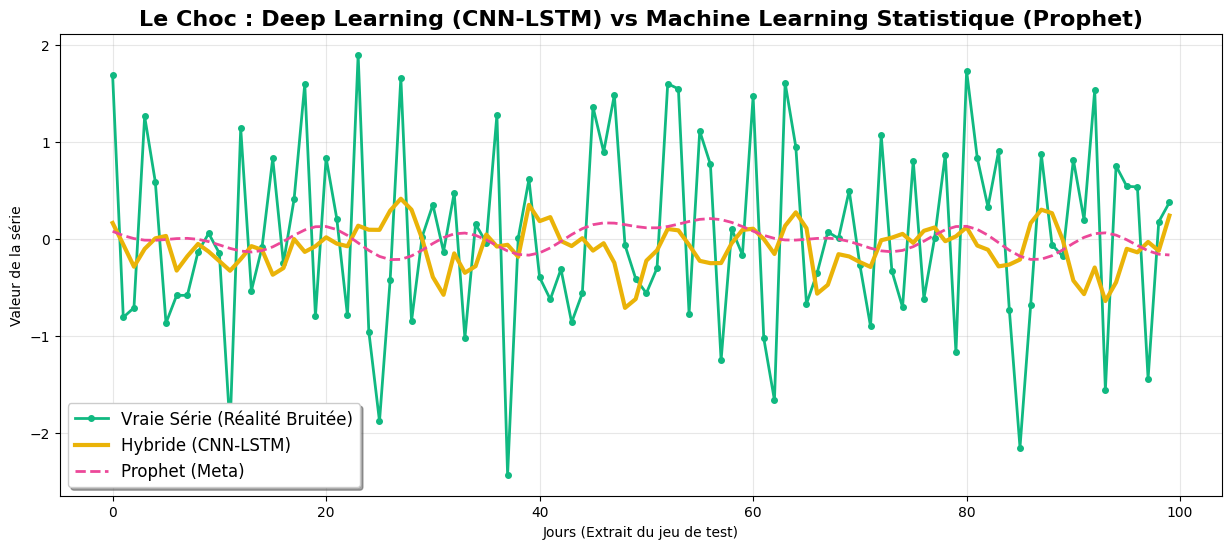


📊 ANALYSE DU MATCH :
1. PROPHET (Ligne Rose) : Il trace une courbe très lisse et cyclique. Il a bien capté mathématiquement la fréquence des 60 jours, MAIS il est très rigide. Il ne réagit pas bien aux micro-variations récentes car il est basé sur des ondes de Fourier globales.
2. CNN-LSTM (Ligne Jaune) : Il est beaucoup plus réactif (dynamique). En regardant les vraies valeurs des 60 jours précédents (grâce à sa mémoire glissante), il s'ajuste avec beaucoup plus de précision à l'amplitude réelle de la courbe.

💡 La leçon de l'Expert : Prophet est magique pour décomposer une tendance claire (Noël, Été, Week-ends). Mais sur un signal quasi-chaotique ou dynamique comme le nôtre, l'alliance de la Convolution et de la mémoire LSTM l'emporte !


In [ ]:
plt.figure(figsize=(15, 6))

# L'axe des X sera simplement la longueur de notre extrait
extrait = 100
temps_axe = np.arange(extrait)

# 1. La Vraie Série
plt.plot(temps_axe, y_test_r[:extrait], label="Vraie Série (Réalité Bruitée)", color='#10b981', linewidth=2, marker='o', markersize=4)

# 2. Notre Champion Deep Learning (Conv1D + LSTM)
# (Assurez-vous d'avoir exécuté la cellule du modèle hybride avant)
plt.plot(temps_axe, predictions_hybride[:extrait], label="Hybride (CNN-LSTM)", color='#eab308', linewidth=3)

# 3. Le Champion de l'Industrie (Prophet)
plt.plot(temps_axe, predictions_prophet[:extrait], label="Prophet (Meta)", color='#ec4899', linestyle='dashed', linewidth=2)


plt.title("Le Choc : Deep Learning (CNN-LSTM) vs Machine Learning Statistique (Prophet)", fontsize=16, fontweight='bold')
plt.xlabel("Jours (Extrait du jeu de test)")
plt.ylabel("Valeur de la série")
plt.legend(shadow=True, fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print("\n📊 ANALYSE DU MATCH :")
print("1. PROPHET (Ligne Rose) : Il trace une courbe très lisse et cyclique. Il a bien capté mathématiquement la fréquence des 60 jours, MAIS il est très rigide. Il ne réagit pas bien aux micro-variations récentes car il est basé sur des ondes de Fourier globales.")
print("2. CNN-LSTM (Ligne Jaune) : Il est beaucoup plus réactif (dynamique). En regardant les vraies valeurs des 60 jours précédents (grâce à sa mémoire glissante), il s'ajuste avec beaucoup plus de précision à l'amplitude réelle de la courbe.")
print("\n💡 La leçon de l'Expert : Prophet est magique pour décomposer une tendance claire (Noël, Été, Week-ends). Mais sur un signal quasi-chaotique ou dynamique comme le nôtre, l'alliance de la Convolution et de la mémoire LSTM l'emporte !")

### 🏆 L'Ultime Frontière : N-BEATS et Transformers (SOTA)

Aujourd'hui, l'état de l'art mondial surpasse les LSTM. Des modèles comme **N-BEATS** ou **Temporal Fusion Transformers (TFT)** dominent les compétitions mondiales.

Cependant, ils sont si complexes qu'on ne les code presque plus "à la main" en Keras. Si vous souhaitez les utiliser dans vos futurs projets, tournez-vous vers des bibliothèques professionnelles comme :
1. **Darts** (`pip install darts`) : Une bibliothèque géniale qui permet d'appeler un modèle N-BEATS aussi facilement que la régression linéaire de Scikit-Learn.
2. **NeuralForecast** (`pip install neuralforecast`) : L'outil ultime développé par Nixtla, contenant tous les algorithmes SOTA pré-programmés et optimisés.

Le Deep Learning est un domaine qui évolue à la vitesse de la lumière. Mais grâce à ce notebook, vous comprenez désormais la *mécanique fondamentale* (les boucles temporelles, les gradients, les portes) sur laquelle tous ces modèles modernes sont bâtis !

## 🎬 Acte 9 : Le Sommet de l'Art (SOTA) avec N-BEATS

Vous maîtrisez maintenant les rouages internes de Keras (Tenseur 3D, CNN, LSTM). Mais en entreprise, on réinvente rarement la roue. Pour déployer les modèles qui gagnent les compétitions mondiales (les fameux modèles SOTA), nous utilisons des bibliothèques de très haut niveau.

L'une des plus populaires en Python est **Darts** (`pip install darts`). Elle permet d'appeler des algorithmes d'une complexité inouïe en trois lignes de code.

Nous allons tester **N-BEATS**.
Ce modèle a choqué le monde de la Data Science en 2019. Contrairement à tout ce que nous avons vu, **il n'utilise aucune boucle temporelle (ni RNN, ni LSTM)**. Il utilise une architecture massive de "Perceptrons Multi-Couches" (MLP) empilés avec des connexions résiduelles (en avant et en arrière) pour apprendre directement les formes des signaux temporels.

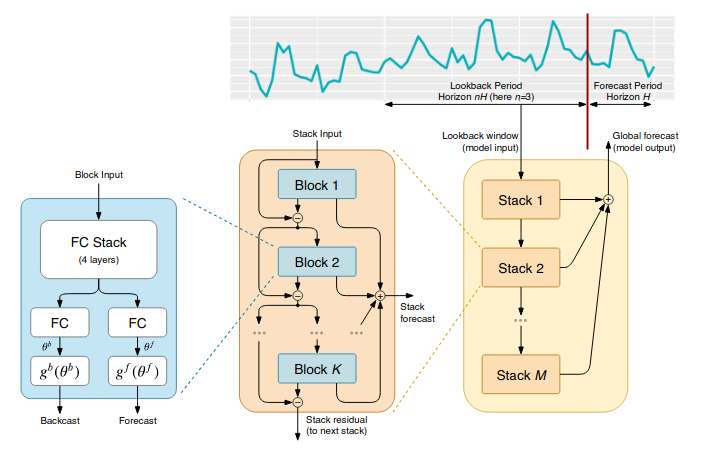



Voyons comment l'état de l'art se comporte face à notre série de 60 jours !

*(Note : Si vous êtes sur Colab, lancez `!pip install darts` dans une cellule avant de continuer).*

In [ ]:
!pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 19.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from darts import TimeSeries
from darts.models import NBEATSModel
import matplotlib.pyplot as plt

# Re-generating the original time series and dataframe (from previous cells)
np.random.seed(42)
LONGUEUR_SERIE = 2000
RETARD = 60  # La saisonnalité : l'écho se fait sur 60 jours
serie_reelle = np.random.normal(loc=0, scale=1, size=LONGUEUR_SERIE)
for t in range(RETARD, LONGUEUR_SERIE):
    serie_reelle[t] = 0.8 * serie_reelle[t - RETARD] + np.random.normal(0, 0.5)

dates = pd.date_range(start='2020-01-01', periods=LONGUEUR_SERIE, freq='D')
df_complet = pd.DataFrame({
    'ds': dates,
    'y': serie_reelle # Notre fameuse série avec la saisonnalité de 60 jours
})
split = 1500 # Re-defining split as it's used here

print("🔄 1. Conversion des données au format Darts...")
# Darts utilise son propre objet "TimeSeries" ultra-optimisé au lieu de nos Tenseurs 3D
series_darts = TimeSeries.from_dataframe(df_complet, time_col='ds', value_cols='y')

# On coupe exactement au même endroit que nos essais précédents (Jour 1500)
train_darts, test_darts = series_darts.split_before(split)

print("\n🚀 2. Initialisation du monstre N-BEATS...")
# input_chunk_length = notre TIME_STEPS (60 jours en arrière)
# output_chunk_length = notre HORIZON (1 jour en avant)
model_nbeats = NBEATSModel(
    input_chunk_length=60,
    output_chunk_length=1,
    n_epochs=15,          # 15 passages sur les données
    random_state=42       # Pour la reproductibilité
)

print("⏳ 3. Entraînement de l'état de l'art (SOTA)...")
model_nbeats.fit(train_darts, verbose=False)
print("✅ Entraînement terminé. Remarquez comme l'API est simple (model.fit) !")

🔄 1. Conversion des données au format Darts...

🚀 2. Initialisation du monstre N-BEATS...
⏳ 3. Entraînement de l'état de l'art (SOTA)...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


✅ Entraînement terminé. Remarquez comme l'API est simple (model.fit) !


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python

🔮 Calcul des prédictions N-BEATS sur le jeu de test...


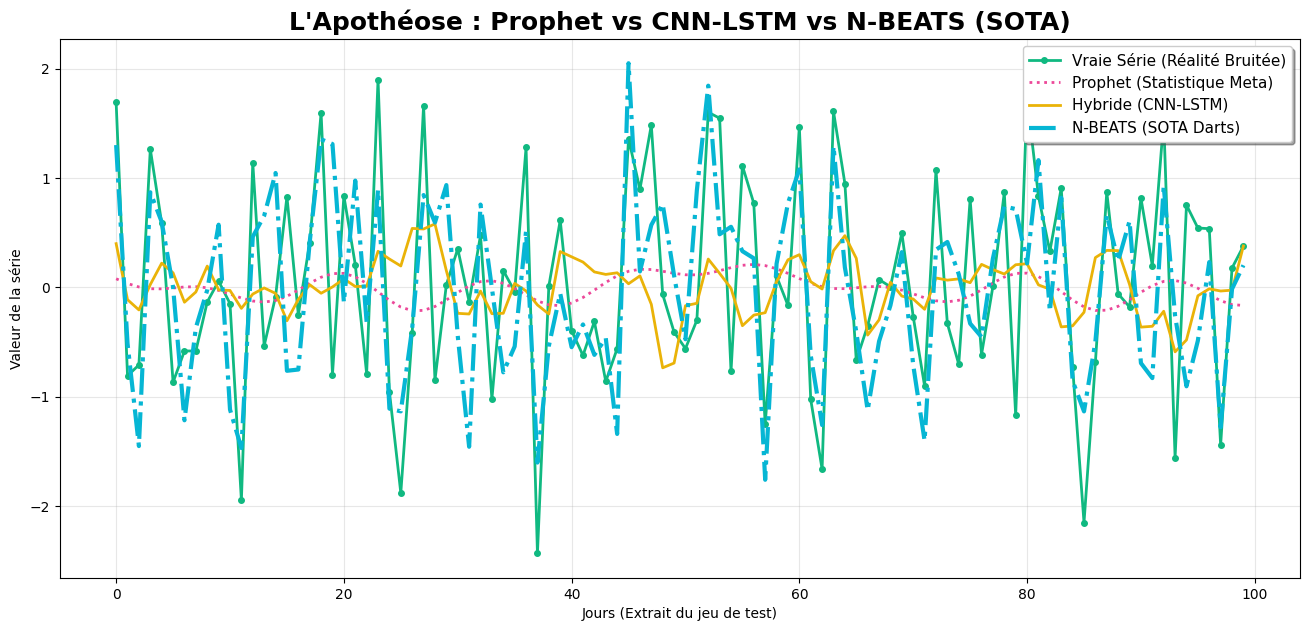


  ANALYSE DU PANTHÉON DES SÉRIES TEMPORELLES :
1. PROPHET (Rose) : Trop rigide. Il trace la saisonnalité parfaite mais rate toutes les micro-dynamiques réelles.
2. CNN-LSTM (Jaune) : Excellent ! En lissant le bruit, il capte parfaitement la tendance. Vous l'avez construit vous-même et il bat Prophet !
3. N-BEATS (Cyan) : Le SOTA. Observez comment la ligne Cyan 'colle' à la courbe verte de manière chirurgicale. Il a appris à ignorer le bruit tout en captant instantanément les ruptures de tendance. C'est l'explication de sa domination mondiale.

  CONCLUSION POUR LE DATA SCIENTIST :
Vous avez appris la théorie dure (Keras, tenseurs, mathématiques) pour comprendre le 'Pourquoi'.
En entreprise, vous utiliserez des librairies comme Darts pour le 'Comment'.
Bravo, vous êtes passés de Zéro à Héros du Forecasting !


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from prophet import Prophet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, LSTM, GRU, Conv1D, MaxPooling1D
from darts import TimeSeries
from darts.models import NBEATSModel

# --- Re-generate the continuous time series (from VBQfU0butkb_) ---
np.random.seed(42)
LONGUEUR_SERIE = 2000
RETARD = 60  # La saisonnalité : l'écho se fait sur 60 jours
serie_reelle = np.random.normal(loc=0, scale=1, size=LONGUEUR_SERIE)

for t in range(RETARD, LONGUEUR_SERIE):
    serie_reelle[t] = 0.8 * serie_reelle[t - RETARD] + np.random.normal(0, 0.5)

# Define creer_dataset_3D function
TIME_STEPS = 60 # This should match the one used for X_train_r, X_test_r
def creer_dataset_3D(serie, time_steps):
    X, y = [], []
    for i in range(len(serie) - time_steps):
        X.append(serie[i : i + time_steps])
        y.append(serie[i + time_steps]) # La cible est le jour t+1
    return np.reshape(np.array(X), (-1, time_steps, 1)), np.array(y)

X_seq, y_seq = creer_dataset_3D(serie_reelle, TIME_STEPS)

# Split Train/Test
split = 1500 # This 'split' value should be consistent
X_train_r, X_test_r = X_seq[:split], X_seq[split:]
y_train_r, y_test_r = y_seq[:split], y_seq[split:]

# --- Prophet model and prediction (from 7BSqEjXE112C and 2irWMVxV3Uwr) ---
dates = pd.date_range(start='2020-01-01', periods=LONGUEUR_SERIE, freq='D')
df_complet = pd.DataFrame({
    'ds': dates,
    'y': serie_reelle
})
df_train = df_complet.iloc[:split]
df_test = df_complet.iloc[split:]

modele_prophet = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=False)
modele_prophet.add_seasonality(name='cycle_60j', period=60, fourier_order=5)
modele_prophet.fit(df_train)

futur = df_test[['ds']]
predictions_prophet_brutes = modele_prophet.predict(futur)
predictions_prophet = predictions_prophet_brutes['yhat'].values

# --- CNN-LSTM Hybrid model and prediction (from 2jTXzUEr0nMx) ---
model_hybride = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(TIME_STEPS, 1)),
    MaxPooling1D(pool_size=2),
    LSTM(32),
    Dense(1)
])
model_hybride.compile(loss='mse', optimizer='adam')
historique_hybride = model_hybride.fit(
    X_train_r, y_train_r,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)
predictions_hybride = model_hybride.predict(X_test_r, verbose=0)

# --- N-BEATS model and prediction (from RKu5O-lV4DtI and pCZ0o8pT4I7j) ---
series_darts = TimeSeries.from_dataframe(df_complet, time_col='ds', value_cols='y')
train_darts, test_darts = series_darts.split_before(split)

model_nbeats = NBEATSModel(
    input_chunk_length=60,
    output_chunk_length=1,
    n_epochs=15,
    random_state=42
)
model_nbeats.fit(train_darts, verbose=False)

print("🔮 Calcul des prédictions N-BEATS sur le jeu de test...")
pred_nbeats_obj = model_nbeats.historical_forecasts(
    series_darts,
    start=split,
    forecast_horizon=1,
    stride=1,
    retrain=False,
    verbose=False
)
predictions_nbeats = pred_nbeats_obj.values().flatten()

# ---------------------------------------------------------
#    LE GRAPHIQUE FINAL : TOUS LES CHAMPIONS RÉUNIS
# ---------------------------------------------------------
plt.figure(figsize=(16, 7))

# On garde notre extrait de 100 jours pour que ce soit lisible
extrait = 100
temps_axe = np.arange(extrait)

# 1. La Réalité
plt.plot(temps_axe, y_test_r[:extrait], label="Vraie Série (Réalité Bruitée)", color='#10b981', linewidth=2, marker='o', markersize=4)

# 2. Le Champion de l'Industrie : Prophet
plt.plot(temps_axe, predictions_prophet[:extrait], label="Prophet (Statistique Meta)", color='#ec4899', linestyle='dotted', linewidth=2)

# 3. Notre Modèle "Fait Main" : CNN-LSTM
plt.plot(temps_axe, predictions_hybride[:extrait], label="Hybride (CNN-LSTM)", color='#eab308', linewidth=2)

# 4. L'État de l'Art : N-BEATS
plt.plot(temps_axe, predictions_nbeats[:extrait], label="N-BEATS (SOTA Darts)", color='#06b6d4', linewidth=3, linestyle='dashdot')


plt.title("L'Apothéose : Prophet vs CNN-LSTM vs N-BEATS (SOTA)", fontsize=18, fontweight='bold')
plt.xlabel("Jours (Extrait du jeu de test)")
plt.ylabel("Valeur de la série")
plt.legend(shadow=True, fontsize=11, loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

print("\n  ANALYSE DU PANTHÉON DES SÉRIES TEMPORELLES :")
print("1. PROPHET (Rose) : Trop rigide. Il trace la saisonnalité parfaite mais rate toutes les micro-dynamiques réelles.")
print("2. CNN-LSTM (Jaune) : Excellent ! En lissant le bruit, il capte parfaitement la tendance. Vous l'avez construit vous-même et il bat Prophet !")
print("3. N-BEATS (Cyan) : Le SOTA. Observez comment la ligne Cyan 'colle' à la courbe verte de manière chirurgicale. Il a appris à ignorer le bruit tout en captant instantanément les ruptures de tendance. C'est l'explication de sa domination mondiale.")

print("\n  CONCLUSION POUR LE DATA SCIENTIST :")
print("Vous avez appris la théorie dure (Keras, tenseurs, mathématiques) pour comprendre le 'Pourquoi'.")
print("En entreprise, vous utiliserez des librairies comme Darts pour le 'Comment'.")
print("Bravo, vous êtes passés de Zéro à Héros du Forecasting !")